In [140]:
import nltk
from spacy.tokenizer import Tokenizer
from spacy.lang.en import English
import spacy
from spacy.attrs import ORTH
from transformers import BertTokenizer
from collections import Counter
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np

### 1

In [2]:
def load_file_content():
    f = open("wsj_untokenized.txt", "r")
    content = f.readlines()
    # Preprocessing - text normalization
    # 1. Lowercase
    # 2. Lemmatization
    return content[0].lower()

In [3]:
def ntlk_tokenize(file_content):
    tokens = nltk.word_tokenize(file_content)
    types = set(tokens)
    ttr = len(set(tokens))/len(tokens)
    fdist = nltk.FreqDist(tokens)
    hapax_legomena = fdist.hapaxes()
    hapax_dislegomena = list(fdist.values()).count(2)
    return tokens, types, ttr, hapax_legomena, hapax_dislegomena

In [4]:
def spacy_tokenize(file_content):
    nlp = English()
    tokenizer = nlp.tokenizer
    tokens = tokenizer(file_content)
    types = { token.orth for token in tokens }
    ttr = len(set(types))/len(tokens)
    count_dict = tokens.count_by(ORTH)
    hapax_legomena = list(count_dict.values()).count(1)
    hapax_dislegomena = list(count_dict.values()).count(2)

    return tokens, types, ttr, hapax_legomena, hapax_dislegomena

In [5]:
def bert_tokenize(file_content):
    tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
    tokens = tokenizer.tokenize(file_content,  max_length=200000)
    types = set(tokens)
    ttr = len(set(tokens))/len(tokens)
    word_counts = Counter(tokens)
    hapax_legomena = list(word_counts.values()).count(1)
    hapax_dislegomena = list(word_counts.values()).count(2)

    return tokens, types, ttr, hapax_legomena, hapax_dislegomena

In [6]:
file_content = load_file_content()
nltk_tokens, nltk_types, nltk_ttr, nltk_hapax_legomena, nltk_hapax_dislegomena = ntlk_tokenize(file_content)
print("NLTK")
print(f"#Tokens: {len(nltk_tokens)}")
print(f"#Types: {len(set(nltk_tokens))}")
print(f"TTR: {len(set(nltk_tokens))/len(nltk_tokens)}")
print(f"Hapax legomena: {len(nltk_hapax_legomena)}")
print(f"Hapax dislegomena: {nltk_hapax_dislegomena}")

NLTK
#Tokens: 93356
#Types: 11017
TTR: 0.1180106259908308
Hapax legomena: 5615
Hapax dislegomena: 1702


In [7]:
spacy_tokens, spacy_types, spacy_ttr, spacy_hapax_legomena, spacy_hapax_dislegomena = spacy_tokenize(file_content)
print("spaCy")
print(f"#Tokens: {len(spacy_tokens)}")
print(f"#Types: {len(spacy_types)}")
print(f"TTR: {len(set(spacy_types))/len(spacy_tokens)}")
print(f"Hapax legomena: {spacy_hapax_legomena}")
print(f"Hapax dislegomena: {spacy_hapax_dislegomena}")

spaCy
#Tokens: 97152
#Types: 10445
TTR: 0.10751194005270093
Hapax legomena: 5072
Hapax dislegomena: 1659


In [8]:
bert_tokens, bert_types, bert_ttr, bert_hapax_legomena, bert_hapax_dislegomena = bert_tokenize(file_content)
print("Bert")
print(f"#Tokens: {len(bert_tokens)}")
print(f"#Types: {len(bert_types)}")
print(f"TTR: {bert_ttr}")
print(f"Hapax legomena: {bert_hapax_legomena}")
print(f"Hapax dislegomena: {bert_hapax_dislegomena}")
print("============")

Bert
#Tokens: 117968
#Types: 8544
TTR: 0.07242642072426421
Hapax legomena: 2915
Hapax dislegomena: 1381


---

### 2

In [9]:
def tokenize_nltk(sentence):
    nltk_tokens = nltk.word_tokenize(sentence)
    print(f"NLTK tokens:\n{nltk_tokens}\n===============")

In [10]:
def tokenize_spacy(sentence):
    nlp = English()
    tokenizer = nlp.tokenizer
    spacy_tokens = tokenizer(sentence)
    st = [ str(token) for token in spacy_tokens ]
    print(f"spaCy tokens:\n{st}\n===============")

In [11]:
def tokenize_bert(sentence):
    tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
    bert_tokens = tokenizer.tokenize(sentence,  max_length=200000)
    print(f"BERT tokens:\n{bert_tokens}\n===============")

In [12]:
sentence = "Pierre Vinken, 61 years old, will join the board as a nonexecutive director Nov. 29."
tokenize_nltk(sentence)
tokenize_spacy(sentence)
tokenize_bert(sentence)

NLTK tokens:
['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
spaCy tokens:
['Pierre', 'Vinken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'nonexecutive', 'director', 'Nov.', '29', '.']
BERT tokens:
['Pierre', 'Vin', '##ken', ',', '61', 'years', 'old', ',', 'will', 'join', 'the', 'board', 'as', 'a', 'none', '##xe', '##cut', '##ive', 'director', 'Nov', '.', '29', '.']


---

### 3

#### NLTK

In [15]:
nltk_appearance_threshold = int(0.3*len(nltk_tokens))
nltk_fdist = nltk.FreqDist(nltk_tokens)
nltk_token_collection = {}
nltk_total_appearance_count = 0
for tkn, freq in nltk_fdist.most_common():
    if nltk_total_appearance_count + freq < nltk_appearance_threshold:
        nltk_token_collection[tkn] = freq
        nltk_total_appearance_count += freq
    else:
        break

In [16]:
print(f"NLTK\n30% of token count:{nltk_appearance_threshold}\nType apperance sum: {nltk_total_appearance_count}.")

NLTK
30% of token count:28006
Type apperance sum: 27882.


#### spaCY

In [17]:
spacy_appearance_threshold = int(0.3*len(spacy_tokens))
# Convert to list of strings for FreqDist() to work
spacy_token_strings = [ token.text for token in spacy_tokens ]
spacy_fdist = nltk.FreqDist(spacy_token_strings)
spacy_token_collection = {}
spacy_total_appearance_count = 0
for tkn, freq in spacy_fdist.most_common():
    if spacy_total_appearance_count + freq < spacy_appearance_threshold:
        spacy_token_collection[tkn] = freq
        spacy_total_appearance_count += freq
    else:
        break

In [18]:
print(f"spaCy\n30% of token count:{spacy_appearance_threshold}\nType apperance sum: {spacy_total_appearance_count}.")

spaCy
30% of token count:29145
Type apperance sum: 28729.


#### BERT

In [19]:
bert_appearance_threshold = int(0.3*len(bert_tokens))
bert_fdist = nltk.FreqDist(bert_tokens)
bert_token_collection = {}
bert_total_appearance_count = 0
for tkn, freq in bert_fdist.most_common():
    if bert_total_appearance_count + freq < bert_appearance_threshold:
        bert_token_collection[tkn] = freq
        bert_total_appearance_count += freq
    else:
        break

In [20]:
print(f"BERT\n30% of token count:{bert_appearance_threshold}\nType apperance sum: {bert_total_appearance_count}.")

BERT
30% of token count:35390
Type apperance sum: 35265.


In [30]:
# Token count
print(list(map(len, [nltk_token_collection, spacy_token_collection, bert_token_collection])))

[14, 12, 13]


In [110]:
# Plotting
data = {
    "NLTK Type": list(nltk_token_collection.keys()),
    "NLTK Freq": list(nltk_token_collection.values()),
    "spaCy Type": list(spacy_token_collection.keys()),
    "spaCy Freq": list(spacy_token_collection.values()),
    "BERT Type": list(bert_token_collection.keys()),
    "BERT Freq": list(bert_token_collection.values())
}

df = pd.DataFrame(dict([(key, pd.Series(value)) for key, value in data.items()]))
df.style.set_properties(**{"text-align": "center"})

# Fix column types to avoid trailing zeroes
freq_columns = ["NLTK Freq", "spaCy Freq", "BERT Freq"]
for col in freq_columns:
    df[col] = df[col].astype("Int32")

In [111]:
df

,NLTK Type,NLTK Freq,spaCy Type,spaCy Freq,BERT Type,BERT Freq
0,",",4823,.,5020,.,6363
1,the,4757,",",4823,",",5026
2,.,3645,the,4763,the,4767
3,of,2318,of,2319,',4117
4,to,2175,to,2180,of,2320
5,a,1967,a,1991,to,2226
6,in,1760,in,1773,a,2150
7,and,1534,and,1541,in,1940
8,'',959,'',1372,-,1733
9,'s,865,-,1231,and,1549


In [129]:
# Find type intersection
nltk_set = set(nltk_token_collection.keys())
spacy_set = set(spacy_token_collection.keys())
bert_set = set(bert_token_collection.keys())

intersection = nltk_set.intersection(spacy_set, bert_set)
print(f"Common types in all methods: {len(intersection)}")

Common types in all methods: 9


---

### 4

In order to find the best `A` value we need to find the minimum distance between the actual frequencies and the predicted ones from Zipf's law. For this case, I found the best distance measurement to be Mean Square Error - MSE.

In [206]:
def find_best_a_const(tokens):
    fdist = nltk.FreqDist(tokens)
    N = len(tokens)
    
    # Sort frequencies in descending order
    actual_freqs = np.array([count for word, count in fdist.most_common()])
    ranks = np.arange(1, len(actual_freqs) + 1)
    
    # Best A option
    a_options = np.linspace(start=0.1, stop=1.0, num=10)
    best_a = 0.1
    min_mse = float("inf")
    
    # Find best A value
    for a in a_options:
        # Zipf: freq = (A * N) / rank
        predicted_freqs = (a * N) / ranks
        # MSE gave the most accurate results on log values
        mse = np.mean((np.log(actual_freqs) - np.log(predicted_freqs))**2)
        
        if mse < min_mse:
            min_mse = mse
            best_a = a
    
    print(f"\"The best fit constant is A = {best_a}\"")

    return ranks, actual_freqs, best_a

In [207]:
def plot_zipf_law_approximation(ranks, actual_freqs, best_a, fig_name):
    # Build the log-log plot of ranks-frequencies
    plt.figure(figsize=(10, 6))
    
    # Aactual measurements
    plt.loglog(ranks, actual_freqs, label="Actual Measurements", color="blue", linewidth=2)
    
    # Zipf predictions
    zipf_prediction = (best_a * N) / ranks
    plt.loglog(ranks, zipf_prediction, label=f"Zipf's Law Prediction (A={best_a})", 
               color="red", linestyle="--", alpha=0.8)
    
    plt.title(f"Zipf's Law Comparison (NLTK Tokenization)")
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.legend()
    plt.grid(True, which="both", linestyle="--", alpha=0.5)
    
    # Exzport plot for report
    plt.savefig(fig_name, dpi=300)

"The best fit constant is A = 0.1"


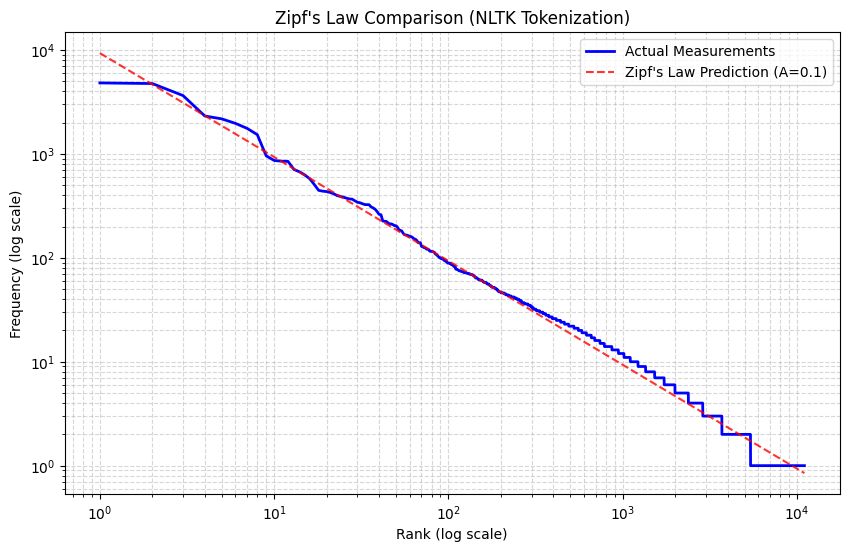

In [208]:
# NLTK
ranks, actual_freqs, best_a = find_best_a_const(nltk_tokens)
plot_zipf_law_approximation(ranks, actual_freqs, best_a, "nltk_zipf_law_comparison.png")

"The best fit constant is A = 0.4"


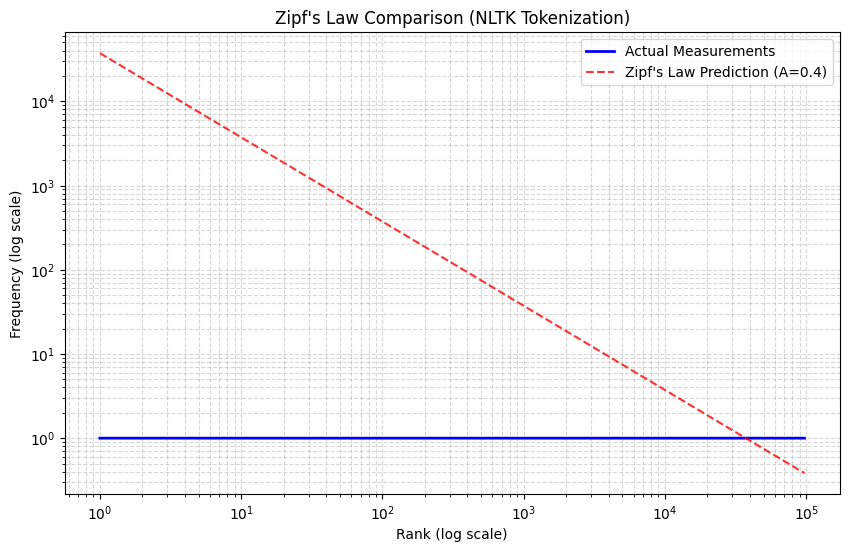

In [209]:
# spaCy
ranks, actual_freqs, best_a = find_best_a_const(spacy_tokens)
plot_zipf_law_approximation(ranks, actual_freqs, best_a, "spacy_zipf_law_comparison.png")

"The best fit constant is A = 0.1"


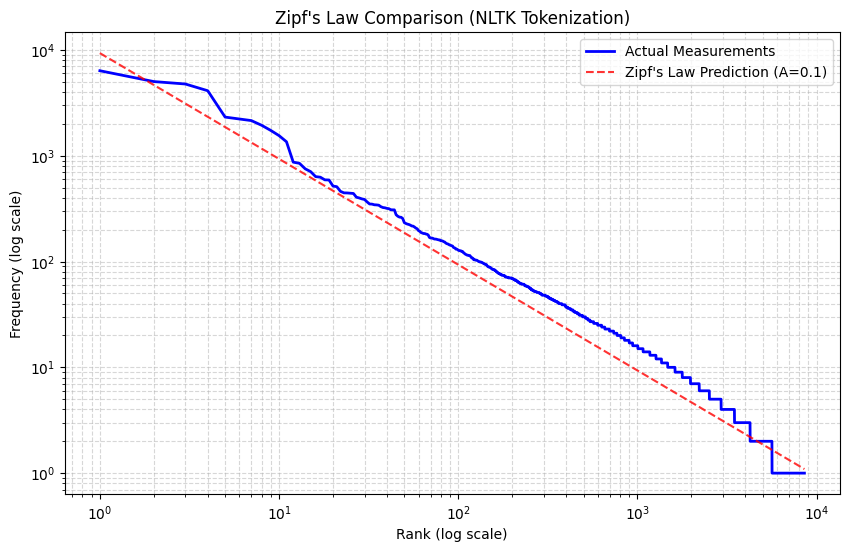

In [210]:
# BERT
ranks, actual_freqs, best_a = find_best_a_const(bert_tokens)
plot_zipf_law_approximation(ranks, actual_freqs, best_a, "bert_zipf_law_comparison.png")

### 5

I used the following prompt in ChatGPT:

    I have the tokens from 3 libraries: NLTK, spaCy and BERT.
    
    Generate Python code for the following assignment:
    Σύμφωνα με τον Νόμο του Zipf, το γινόμενο της πιθανότητας ενός type επί την θέση του στη λίστα των types (ταξινομημένη κατά φθίνουσα σειρά συχνότητας) είναι ίσο με μια σταθερά Α. Βρείτε ποια τιμή της σταθεράς A (εξετάστε τις επιλογές: 0.1, 0.2, 0.3, …, 1.0) ταιριάζει καλύτερα με το συγκεκριμένο σύνολο κείμενων. Δημιουργήστε ένα διάγραμμα όπου ο
    άξονας x είναι η θέση ενός type σε φθίνουσα σειρά συχνότητας και ο άξονας y είναι η συχνότητα του type στην συλλογή. Και οι 2 άξονες να ακολουθούν την λογαριθμική κλίμακα. Δείξτε στο ίδιο διάγραμμα με διαφορετικά χρώματα (i) τις προβλέψεις του νόμου του Zipf (με την καλύτερη τιμή που βρέθηκε για τη σταθερά Α) και (ii) τις πραγματικές μετρήσεις που έγιναν στα κείμενα.
    
    Make sure you generate 2 separate functions: one to find the best A value and another to plot the diagrams. Make sure each function accepts and returns the necessary variables.

Following is the code it generated. While it's not "DRY", it accomplishes the requested task and finds the same Alpha values.

In [200]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter


def find_best_zipf_A(tokens):
    """
    Finds the best Zipf constant A from [0.1, 0.2, ..., 1.0]
    
    Args:
        tokens (list): List of tokens
        
    Returns:
        best_A (float): Best fitting A value
        ranks (np.array): Rank positions
        frequencies (np.array): Actual frequencies
    """
    
    # Count frequencies
    freq_counter = Counter(tokens)
    
    # Sort by descending frequency
    sorted_freqs = sorted(freq_counter.values(), reverse=True)
    frequencies = np.array(sorted_freqs)
    
    # Convert to probabilities
    total_tokens = len(tokens)
    probabilities = frequencies / total_tokens
    
    # Create ranks (1-based)
    ranks = np.arange(1, len(probabilities) + 1)
    
    # Candidate A values
    A_values = np.arange(0.1, 1.1, 0.1)
    
    best_A = None
    best_error = float('inf')
    
    # Evaluate each A
    for A in A_values:
        predicted_prob = A / ranks
        
        # Mean Squared Error
        error = np.mean((probabilities - predicted_prob) ** 2)
        
        if error < best_error:
            best_error = error
            best_A = A
    
    return best_A, ranks, frequencies


def plot_zipf(tokens, best_A):
    """
    Plots actual frequencies vs Zipf prediction (log-log scale)
    
    Args:
        tokens (list): List of tokens
        best_A (float): Best Zipf constant
        
    Returns:
        None
    """
    
    # Count frequencies
    freq_counter = Counter(tokens)
    
    # Sort frequencies
    sorted_freqs = sorted(freq_counter.values(), reverse=True)
    frequencies = np.array(sorted_freqs)
    
    # Convert to probabilities
    total_tokens = len(tokens)
    probabilities = frequencies / total_tokens
    
    # Ranks
    ranks = np.arange(1, len(probabilities) + 1)
    
    # Zipf prediction
    zipf_pred = best_A / ranks
    
    # Plot
    plt.figure()
    
    plt.loglog(ranks, probabilities, label="Actual Data")
    plt.loglog(ranks, zipf_pred, linestyle='--', label=f"Zipf Prediction (A={best_A})")
    
    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency / Probability (log scale)")
    plt.title("Zipf's Law Fit")
    plt.legend()
    
    plt.grid(True, which="both", linestyle="--")
    plt.show()

Best A: 0.1


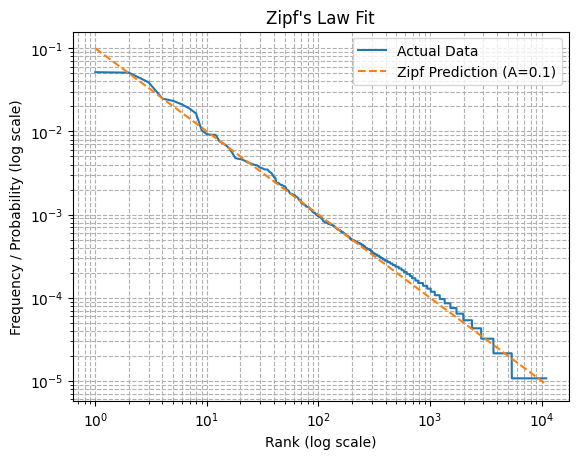

In [203]:
best_A, ranks, frequencies = find_best_zipf_A(nltk_tokens)
print(f"Best A: {best_A}")
plot_zipf(nltk_tokens, best_A)

Best A: 0.1


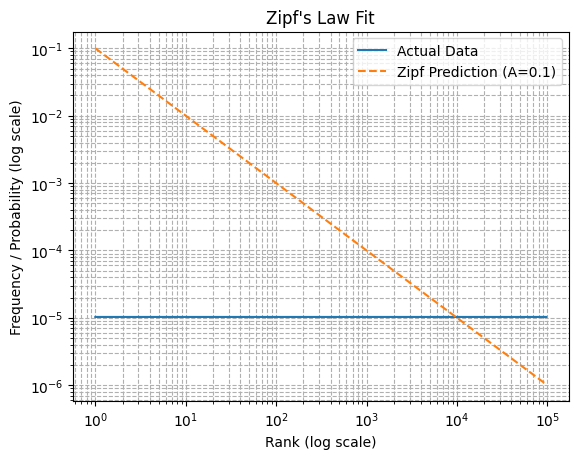

In [204]:
best_A, ranks, frequencies = find_best_zipf_A(spacy_tokens)
print(f"Best A: {best_A}")
plot_zipf(spacy_tokens, best_A)

Best A: 0.1


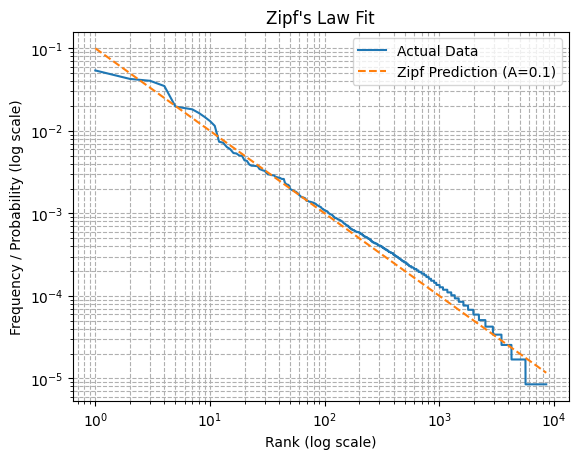

In [205]:
best_A, ranks, frequencies = find_best_zipf_A(bert_tokens)
print(f"Best A: {best_A}")
plot_zipf(bert_tokens, best_A)

---